# Qwen3 1.7B Prediction and Accuracy Evaluation Plot Only - Cleaned Notebook


## Session Map
1. Runtime and project setup
2. Evaluation configuration
3. Evaluation dataset loading
4. Text preparation and tokenization
5. Model and inference setup
6. Metrics and plotting helpers
7. Run evaluation across all organs
8. Print per-label organ summaries
9. Optional Colab cleanup


## Session 1 - Runtime and Project Setup

Steps:
1. Mount Google Drive and prepare the Colab workspace.
2. Clone the project repository into `/content`.
3. Install TPU/XLA-compatible dependencies and verify the runtime.


In [ ]:
from google.colab import drive
import os
import shutil
import subprocess

drive.mount("/content/drive")
%cd /content

REPO_URL = "https://github.com/HangYu8123/SC_Ageing_Prediction.git"
PROJECT_DIR = "/content/SC_Ageing_Prediction"
REFRESH_PROJECT = True

if REFRESH_PROJECT and os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

if not os.path.exists(PROJECT_DIR):
    subprocess.check_call(["git", "clone", REPO_URL, PROJECT_DIR])

print("Project directory:", PROJECT_DIR)


Mounted at /content/drive
/content
Project directory: /content/SC_Ageing_Prediction


In [ ]:
import os
import subprocess
import sys

os.environ["PJRT_DEVICE"] = "TPU"
os.environ["XLA_USE_BF16"] = "1"
os.environ.setdefault("PT_XLA_DEBUG", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

PYTORCH_VERSION = "2.6.0"

def pip_install(packages: list[str], extra_args: list[str] | None = None) -> None:
    args = [sys.executable, "-m", "pip", "install"]
    if extra_args:
        args.extend(extra_args)
    args.extend(packages)
    print("Running:", " ".join(args))
    subprocess.check_call(args)

try:
    import torch  # noqa: F401
    import torch_xla  # noqa: F401
    print("torch:", torch.__version__)
    print("torch_xla:", torch_xla.__version__)
except Exception as exc:
    print("Installing torch_xla because import failed:", repr(exc))
    pip_install(
        [
            f"torch=={PYTORCH_VERSION}",
            f"torch_xla[tpu]=={PYTORCH_VERSION}",
        ],
        extra_args=["-q", "-f", "https://storage.googleapis.com/libtpu-releases/index.html"],
    )

pip_install(
    [
        "transformers>=4.45.0",
        "datasets>=2.19.0",
        "accelerate>=0.33.0",
        "huggingface_hub>=0.24.0",
        "evaluate>=0.4.2",
        "matplotlib>=3.8.0",
        "scikit-learn>=1.3.0",
    ],
    extra_args=["-q", "-U"],
)

print("Dependency setup complete. Restart the runtime if Colab asks for it.")


torch: 2.9.0+cpu
torch_xla: 2.9.0
Running: /usr/bin/python3 -m pip install -q -U transformers>=4.45.0 datasets>=2.19.0 accelerate>=0.33.0 huggingface_hub>=0.24.0 evaluate>=0.4.2 matplotlib>=3.8.0 scikit-learn>=1.3.0
Dependency setup complete. Restart the runtime if Colab asks for it.


In [ ]:
import torch
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr

xr.use_spmd()

print("torch:", torch.__version__)
print("torch_xla:", torch_xla.__version__)
print("PJRT device:", os.environ["PJRT_DEVICE"])
print("Global runtime device count:", xr.global_runtime_device_count())
print("Supported XLA devices:", xm.get_xla_supported_devices())
print("Current XLA device:", torch_xla.device())


torch: 2.9.0+cpu
torch_xla: 2.9.0
PJRT device: TPU
Global runtime device count: 1
Supported XLA devices: ['xla:0']
Current XLA device: xla:0


## Session 2 - Evaluation Configuration

Steps:
1. Define the model checkpoint and output directory.
2. Configure evaluation split names and file prefixes.
3. Set tokenization and inference parameters.


In [ ]:
from pathlib import Path
import os
import random

import numpy as np
import torch

DATA_DIR = Path(PROJECT_DIR) / "fine_tune_chunks"
MODEL_ID = "DaisyCuttie/QWEN3-1.7B-EIGHT-ORGANS-EXTENDED-FULL-LENGTH"
OUTPUT_DIR = "/content/qwen3_prediction_acc_outputs"

EVAL_PART = 11
MAX_LENGTH = 1024
GLOBAL_EVAL_BS = 128
SEED = 42
DTYPE = torch.bfloat16

ORGAN_PREFIXES = {
    "bladder": "bladder",
    "brain": "brain",
    "bone": "bone-marrow",
    "limb": "limb-muscle",
    "kidney": "kidney",
    "liver": "liver",
    "lung": "lung",
    "heart": "heart",
}

LABEL2ID = {"1m": 0, "3m": 1, "18m": 2, "24m": 3, "30m": 4}
ID2LABEL = {label_id: label for label, label_id in LABEL2ID.items()}
LABEL_SUFFIX = "Answer with exactly one label from {1m, 3m, 18m, 24m, 30m}."

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

print("Evaluation data directory:", DATA_DIR)
print("Model ID:", MODEL_ID)
print("Output directory:", OUTPUT_DIR)


Evaluation data directory: /content/SC_Ageing_Prediction/fine_tune_chunks
Model ID: DaisyCuttie/QWEN3-1.7B-EIGHT-ORGANS-EXTENDED-FULL-LENGTH
Output directory: /content/qwen3_prediction_acc_outputs


## Session 3 - Evaluation Dataset Loading

Steps:
1. Build the overall validation split from all organ files.
2. Load one separate evaluation split per organ.
3. Collect everything into a single `DatasetDict`.


In [ ]:
import glob
import json

from datasets import Dataset, DatasetDict, load_dataset
import re

print("Files found:", len(glob.glob(f"{DATA_DIR}/*.json")))
print("Example files:", sorted(glob.glob(f"{DATA_DIR}/*.json"))[:5])



CELL_TYPE_KEYS = (
    "cell_type",
    "celltype",
    "cell type",
    "cell_ontology_class",
    "cell_type_info",
    "celltype_info",
    "annotation",
    "cell_label",
    "type",
)

ORGAN_DISPLAY = {
    "bladder": "Bladder",
    "brain": "Brain",
    "bone": "Bone-Marrow",
    "limb": "Limb-Muscle",
    "kidney": "Kidney",
    "liver": "Liver",
    "lung": "Lung",
    "heart": "Heart",
}

ORGAN_COLORS = {
    "bladder": "#1f77b4",
    "bone": "#ff7f0e",
    "brain": "#2ca02c",
    "heart": "#d62728",
    "kidney": "#9467bd",
    "limb": "#8c564b",
    "liver": "#e377c2",
    "lung": "#7f7f7f",
}

def normalize_cell_type(value: str | None) -> str:
    if not value:
        return "Unknown"
    value = str(value).strip().strip(" .,:;")
    value = re.sub(r"[_-]+", " ", value)
    value = re.sub(r"\s+", " ", value)
    return value or "Unknown"

def infer_cell_type(example: dict) -> str:
    lower_to_key = {str(key).lower(): key for key in example.keys()}
    for wanted in CELL_TYPE_KEYS:
        actual_key = lower_to_key.get(wanted.lower())
        if actual_key is not None:
            value = example.get(actual_key)
            if value is not None and str(value).strip():
                return normalize_cell_type(value)

    text = "\n".join(str(example.get(key, "")) for key in ("instruction", "input", "text"))
    patterns = [
        r"cell\s*type(?:\s*info)?\s*[:=]\s*([^\n;,]+)",
        r"celltype(?:\s*info)?\s*[:=]\s*([^\n;,]+)",
        r"annotation\s*[:=]\s*([^\n;,]+)",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return normalize_cell_type(match.group(1))
    return "Unknown"


def build_eval_files() -> dict[str, str]:
    split_to_file = {}
    for split_name, file_prefix in ORGAN_PREFIXES.items():
        split_to_file[split_name] = str(
            DATA_DIR / f"{file_prefix}_cell_data_part_{EVAL_PART}.json"
        )
    return split_to_file

def load_json_dataset(files: list[str] | str) -> Dataset:
    try:
        return load_dataset("json", data_files=files, split="train")
    except Exception as exc:
        print("Falling back to manual JSON loading:", exc)
        rows = []
        file_list = [files] if isinstance(files, str) else files
        for file_path in file_list:
            with open(file_path, "r") as handle:
                rows.extend(json.load(handle))
        return Dataset.from_list(rows)

split_files = build_eval_files()
validation_files = [split_files[name] for name in ORGAN_PREFIXES.keys()]

raw_splits = {
    "validation": load_json_dataset(validation_files),
}

for split_name, file_path in split_files.items():
    raw_splits[split_name] = load_json_dataset(file_path)

raw = DatasetDict(raw_splits)

print("Validation file sample:", validation_files[0])
print(raw)
print("Columns:", raw["validation"].column_names)
print("Example output label:", raw["validation"][0].get("output"))

# Lightweight metadata aligned to raw["validation"]. This does not change tokenization
# or evaluation; it is only used for the extra grouped plot after prediction.
validation_group_metadata = []
for split_name in ORGAN_PREFIXES.keys():
    for example in raw[split_name]:
        validation_group_metadata.append(
            {
                "organ": split_name,
                "organ_display": ORGAN_DISPLAY.get(split_name, split_name.title()),
                "cell_type": infer_cell_type(example),
            }
        )

print("Validation metadata rows:", len(validation_group_metadata))
print("Example metadata:", validation_group_metadata[:3])


Files found: 199
Example files: ['/content/SC_Ageing_Prediction/fine_tune_chunks/bladder_cell_data_part_1.json', '/content/SC_Ageing_Prediction/fine_tune_chunks/bladder_cell_data_part_10.json', '/content/SC_Ageing_Prediction/fine_tune_chunks/bladder_cell_data_part_10_sorted.json', '/content/SC_Ageing_Prediction/fine_tune_chunks/bladder_cell_data_part_11.json', '/content/SC_Ageing_Prediction/fine_tune_chunks/bladder_cell_data_part_11_sorted.json']


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Validation file sample: /content/SC_Ageing_Prediction/fine_tune_chunks/bladder_cell_data_part_11.json
DatasetDict({
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 8564
    })
    bladder: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 692
    })
    brain: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1741
    })
    bone: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 2288
    })
    limb: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1581
    })
    kidney: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 660
    })
    liver: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 350
    })
    lung: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 817
    })
    heart: Dataset({
        features: ['in

## Session 4 - Text Preparation and Tokenization

Steps:
1. Convert each example into the evaluation prompt format.
2. Map labels into integer class IDs.
3. Tokenize all evaluation splits with fixed padding for TPU stability.


In [ ]:
from transformers import AutoTokenizer, DataCollatorWithPadding

def format_text(example: dict) -> dict:
    instruction = (example.get("instruction") or "").strip()
    cell_input = (example.get("input") or "").strip()
    label = (example.get("output") or "").strip()

    if label not in LABEL2ID:
        raise ValueError(f"Unexpected label: {label}")

    text = f"{instruction}\n\n{cell_input}\n\n{LABEL_SUFFIX}"
    return {"text": text, "label": LABEL2ID[label]}

raw = raw.map(format_text, remove_columns=raw["validation"].column_names)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.bos_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.bos_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def tokenize_batch(batch: dict) -> dict:
    encoded = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )
    encoded["labels"] = batch["label"]
    return encoded

tokenized = raw.map(tokenize_batch, batched=True, remove_columns=raw["validation"].column_names)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=128)

print(tokenized)
print(tokenized["validation"][0].keys())


Map:   0%|          | 0/8564 [00:00<?, ? examples/s]

Map:   0%|          | 0/692 [00:00<?, ? examples/s]

Map:   0%|          | 0/1741 [00:00<?, ? examples/s]

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

Map:   0%|          | 0/1581 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/660 [00:00<?, ? examples/s]

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/817 [00:00<?, ? examples/s]

Map:   0%|          | 0/435 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8564
    })
    bladder: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 692
    })
    brain: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1741
    })
    bone: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2288
    })
    limb: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1581
    })
    kidney: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 660
    })
    liver: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 350
    })
    lung: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 817
    })
    heart: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
       

## Session 5 - Model and Inference Setup

Steps:
1. Load the trained sequence classification checkpoint.
2. Configure an evaluation-only `Trainer`.
3. Prepare TPU-safe inference settings.


In [ ]:
import inspect

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model_kwargs = {
    "num_labels": len(LABEL2ID),
    "id2label": ID2LABEL,
    "label2id": LABEL2ID,
    "trust_remote_code": True,
}

pretrained_signature = inspect.signature(AutoModelForSequenceClassification.from_pretrained)
if "dtype" in pretrained_signature.parameters:
    model_kwargs["dtype"] = DTYPE
else:
    model_kwargs["torch_dtype"] = DTYPE

model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, **model_kwargs)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False
if getattr(model.config, "bos_token_id", None) is None and tokenizer.bos_token_id is not None:
    model.config.bos_token_id = tokenizer.bos_token_id

eval_arg_candidates = {
    "output_dir": OUTPUT_DIR,
    "per_device_eval_batch_size": GLOBAL_EVAL_BS,
    "bf16": True,
    "dataloader_drop_last": False,
    "dataloader_pin_memory": False,
    "dataloader_num_workers": 0,
    "remove_unused_columns": False,
    "report_to": "none",
    "seed": SEED,
}

valid_eval_args = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
eval_arg_candidates = {
    key: value for key, value in eval_arg_candidates.items() if key in valid_eval_args
}
eval_args = TrainingArguments(**eval_arg_candidates)

trainer_kwargs = {
    "model": model,
    "args": eval_args,
    "data_collator": data_collator,
}

trainer_init_params = set(inspect.signature(Trainer.__init__).parameters.keys())
if "processing_class" in trainer_init_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_init_params:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

print("Trainer ready for evaluation.")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Trainer ready for evaluation.


## Session 6 - Metrics and Plotting Helpers

Steps:
1. Compute confusion matrices and classification reports.
2. Build summary metrics for each split.
3. Save one metrics figure and one confusion matrix per split.


In [ ]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches


LABEL_IDS = sorted(ID2LABEL.keys())
LABEL_NAMES = [ID2LABEL[label_id] for label_id in LABEL_IDS]

def get_logits(predictions):
    if isinstance(predictions, (tuple, list)):
        return predictions[0]
    return predictions

def evaluate_split(split_name: str, y_true: np.ndarray, logits: np.ndarray, metrics: dict | None = None) -> dict:
    y_true = np.asarray(y_true).reshape(-1)
    logits = np.asarray(logits)
    y_pred = np.argmax(logits, axis=-1).reshape(-1)

    cm = confusion_matrix(y_true, y_pred, labels=LABEL_IDS)

    per_label_recall = {}
    for row_index, label_id in enumerate(LABEL_IDS):
        denom = cm[row_index, :].sum()
        per_label_recall[ID2LABEL[label_id]] = float(cm[row_index, row_index] / denom) if denom > 0 else float("nan")

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=LABEL_IDS,
        target_names=LABEL_NAMES,
        digits=4,
        output_dict=True,
        zero_division=0,
    )

    derived_metrics = {
        "accuracy": float(report_dict.get("accuracy", float("nan"))),
        "macro_precision": float(report_dict.get("macro avg", {}).get("precision", float("nan"))),
        "macro_recall": float(report_dict.get("macro avg", {}).get("recall", float("nan"))),
        "macro_f1": float(report_dict.get("macro avg", {}).get("f1-score", float("nan"))),
        "weighted_f1": float(report_dict.get("weighted avg", {}).get("f1-score", float("nan"))),
    }

    overall_metrics = dict(metrics or {})
    overall_metrics[f"final_{split_name}_accuracy"] = derived_metrics["accuracy"]
    overall_metrics[f"final_{split_name}_macro_f1"] = derived_metrics["macro_f1"]

    return {
        "split": split_name,
        "num_samples": int(len(y_true)),
        "overall_metrics": overall_metrics,
        "derived_metrics": derived_metrics,
        "per_label_accuracy_rowwise": per_label_recall,
        "confusion_matrix": {"labels": LABEL_NAMES, "matrix": cm.tolist()},
        "classification_report": report_dict,
    }

def plot_accuracy_f1_recall(split_result: dict, output_dir: str) -> None:
    labels = split_result["confusion_matrix"]["labels"]
    report = split_result["classification_report"]

    recalls = []
    f1s = []
    supports = []
    for label in labels:
        recalls.append(split_result["per_label_accuracy_rowwise"].get(label, float("nan")))
        if label in report:
            f1s.append(float(report[label].get("f1-score", 0.0)))
            supports.append(int(report[label].get("support", 0)))
        else:
            f1s.append(0.0)
            supports.append(0)

    recalls_plot = [0.0 if not np.isfinite(value) else float(value) for value in recalls]
    overall_acc = split_result["derived_metrics"]["accuracy"]
    macro_recall = split_result["derived_metrics"]["macro_recall"]
    macro_f1 = split_result["derived_metrics"]["macro_f1"]

    x = np.arange(len(labels))
    bar_width = 0.36
    inner_gap = 0.025

    plt.figure(figsize=(max(10, 0.7 * len(labels)), 6))
    plt.bar(x - (bar_width / 2 + inner_gap / 2), recalls_plot, bar_width, label="Per-class Recall", color="#004567")
    plt.bar(x + (bar_width / 2 + inner_gap / 2), f1s, bar_width, label="Per-class F1", color="#E85A0E")

    if np.isfinite(overall_acc):
        plt.axhline(overall_acc, color="#4D8EC0", linestyle="--", linewidth=2, label=f"Overall Accuracy = {overall_acc:.4f}")

    xticks = [f"{label}\n(n={support})" for label, support in zip(labels, supports)]
    plt.xticks(x, xticks, rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(f"[{split_result['split']}] Per-class Recall/F1 + Overall Accuracy 1K Length Model")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(True)

    ax.yaxis.grid(True, linestyle="-", linewidth=0.8, alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

    plt.gca().text(
        1.01,
        0.5,
        f"Macro Recall: {macro_recall:.4f}\nMacro F1: {macro_f1:.4f}\nOverall Acc: {overall_acc:.4f}",
        transform=plt.gca().transAxes,
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round", alpha=0.2),
    )
    plt.legend()
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    fig_path = os.path.join(output_dir, f"final_{split_result['split']}_metrics.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved metrics figure to:", fig_path)


def plot_confusion_matrix(split_result: dict, output_dir: str) -> None:
    labels = split_result["confusion_matrix"]["labels"]
    cm = np.array(split_result["confusion_matrix"]["matrix"], dtype=np.int64)

    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = np.divide(cm, row_sums, where=(row_sums != 0))
        cm_norm = np.nan_to_num(cm_norm)

    n = len(labels)

    # Separate diagonal and off-diagonal values
    diag_data = np.full_like(cm_norm, np.nan, dtype=float)
    offdiag_data = np.full_like(cm_norm, np.nan, dtype=float)

    for i in range(n):
        for j in range(n):
            if i == j:
                diag_data[i, j] = cm_norm[i, j]
            else:
                offdiag_data[i, j] = cm_norm[i, j]

    # Similar style to your second image
    green_cmap = LinearSegmentedColormap.from_list(
        "agreement_green",
        ["#DDF4DD", "#66C56F", "#006D2C"]
    )

    red_cmap = LinearSegmentedColormap.from_list(
        "soft_difference",
        ["#FAF7F2", "#F2D6C9", "#D98C72"]
    )

    fig, ax = plt.subplots(figsize=(max(7, 0.8 * n), max(6, 0.8 * n)))

    plt.imshow(
        offdiag_data,
        cmap=red_cmap,
        vmin=0,
        vmax=0.25
    )

    plt.imshow(
        diag_data,
        cmap=green_cmap,
        vmin=0.78,
        vmax=0.90
    )

    # Axis labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"[{split_result['split']}] Confusion Matrix 1K Length Model")

    # White grid lines between cells
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Remove outer frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add text
    for i in range(n):
        for j in range(n):
            value = cm_norm[i, j]

            if i == j:
                cell_text = f"{cm[i, j]}\n{cm_norm[i, j]:.2f}"
            else:
                cell_text = f"{cm_norm[i, j]:.2f}"

            plt.text(
                j,
                i,
                cell_text,
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    fig_path = os.path.join(output_dir, f"final_{split_result['split']}_confusion_matrix.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved confusion matrix figure to:", fig_path)

def summarize_by_organ_cell_type(y_true: np.ndarray, y_pred: np.ndarray, metadata: list[dict]) -> list[dict]:
    rows = []
    for organ in ORGAN_PREFIXES.keys():
        cell_types = sorted({row["cell_type"] for row in metadata if row["organ"] == organ})
        for cell_type in cell_types:
            idx = [
                i
                for i, row in enumerate(metadata)
                if row["organ"] == organ and row["cell_type"] == cell_type
            ]
            if not idx:
                continue
            group_true = np.asarray(y_true)[idx]
            group_pred = np.asarray(y_pred)[idx]
            rows.append(
                {
                    "organ": organ,
                    "organ_display": ORGAN_DISPLAY.get(organ, organ.title()),
                    "cell_type": cell_type,
                    "n": int(len(idx)),
                    "accuracy": float(np.mean(group_true == group_pred)),
                    "macro_f1": float(f1_score(group_true, group_pred, labels=LABEL_IDS, average="macro", zero_division=0)),
                }
            )
    return rows


def plot_organ_cell_type_summary(rows: list[dict], output_dir: str, metric: str = "accuracy", min_samples: int = 1) -> None:
    plot_rows = [row for row in rows if row["n"] >= min_samples and np.isfinite(row[metric])]
    plot_rows.sort(key=lambda row: (list(ORGAN_PREFIXES.keys()).index(row["organ"]), row["cell_type"].lower()))
    if not plot_rows:
        print("No organ/cell-type rows available for plotting.")
        return

    labels = [row["cell_type"] for row in plot_rows]
    values = [row[metric] for row in plot_rows]
    colors = [ORGAN_COLORS.get(row["organ"], "#333333") for row in plot_rows]

    fig_width = max(16, 0.46 * len(plot_rows))
    fig, ax = plt.subplots(figsize=(fig_width, 7))
    x = np.arange(len(plot_rows))
    ax.bar(x, values, color=colors, edgecolor="white", linewidth=0.8)

    ax.set_title("Model Performance Summary", fontsize=16, pad=22)
    ax.set_xlabel("Cell Types", fontsize=14)
    ax.set_ylabel("Model Accuracy" if metric == "accuracy" else "Model Macro-F1", fontsize=14)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)
    ax.set_axisbelow(True)

    legend_handles = [
        patches.Patch(color=ORGAN_COLORS[organ], label=ORGAN_DISPLAY.get(organ, organ.title()))
        for organ in ORGAN_PREFIXES.keys()
        if any(row["organ"] == organ for row in plot_rows)
    ]
    ax.legend(handles=legend_handles, title="Organ", loc="upper right", frameon=True, fontsize=9, title_fontsize=9)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    fig_path = os.path.join(output_dir, f"final_organ_cell_type_{metric}_summary.png")
    plt.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved organ/cell-type summary figure to:", fig_path)


## Session 7 - Run Evaluation Across All Organs

Steps:
1. Run one prediction pass for the overall validation split.
2. Run one prediction pass per organ split.
3. Save JSON summaries, plots, and the evaluated model artifacts.


In [ ]:
results = {}
all_y_true_for_group_plot = None
all_y_pred_for_group_plot = None
split_order = ["validation"] + list(ORGAN_PREFIXES.keys())
split_alias = {"validation": "all"}

for split_name in split_order:
    display_name = split_alias.get(split_name, split_name)
    dataset = tokenized[split_name]

    pred_out = trainer.predict(dataset, metric_key_prefix=f"final_{display_name}")
    logits = get_logits(pred_out.predictions)
    y_true = np.asarray(pred_out.label_ids).reshape(-1)
    metrics = getattr(pred_out, "metrics", {}) or {}

    split_result = evaluate_split(display_name, y_true, logits, metrics=metrics)
    results[display_name] = split_result

    if display_name == "all":
        all_y_true_for_group_plot = y_true.copy()
        all_y_pred_for_group_plot = np.argmax(logits, axis=-1).reshape(-1).copy()

    print("\n==============================")
    print(f"=== Split: {display_name} (n={split_result['num_samples']}) ===")
    print(
        f"Accuracy: {split_result['derived_metrics']['accuracy']:.6f} | "
        f"Macro-F1: {split_result['derived_metrics']['macro_f1']:.6f}"
    )
    print("==============================")

os.makedirs(OUTPUT_DIR, exist_ok=True)

details_path = os.path.join(OUTPUT_DIR, "final_eval_details_by_split.json")
with open(details_path, "w") as handle:
    json.dump(results, handle, indent=2)

try:
    import torch_xla.core.xla_model as xm
    is_master = xm.is_master_ordinal()
except Exception:
    is_master = True

if is_master:
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print("Saved model and tokenizer to:", OUTPUT_DIR)

print("\n===== Summary (all + organs) =====")
for split_name in ["all"] + list(ORGAN_PREFIXES.keys()):
    summary = results[split_name]
    print(
        f"{split_name:>10s} | n={summary['num_samples']:6d} | "
        f"accuracy={summary['derived_metrics']['accuracy']:.6f} | "
        f"macro_f1={summary['derived_metrics']['macro_f1']:.6f}"
    )

print("\nSaved detailed evaluation JSON to:", details_path)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(



=== Split: all (n=8564) ===
Accuracy: 0.843998 | Macro-F1: 0.850022



=== Split: bladder (n=692) ===
Accuracy: 0.900289 | Macro-F1: 0.716743



=== Split: brain (n=1741) ===
Accuracy: 0.840896 | Macro-F1: 0.499843



=== Split: bone (n=2288) ===
Accuracy: 0.762675 | Macro-F1: 0.590907


...


=== Split: liver (n=350) ===
Accuracy: 0.994286 | Macro-F1: 0.760784



=== Split: lung (n=817) ===
Accuracy: 0.840881 | Macro-F1: 0.681873



=== Split: heart (n=435) ===
Accuracy: 0.868966 | Macro-F1: 0.607113


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: /content/qwen3_prediction_acc_outputs

===== Summary (all + organs) =====
       all | n=  8564 | accuracy=0.843998 | macro_f1=0.850022
   bladder | n=   692 | accuracy=0.900289 | macro_f1=0.716743
     brain | n=  1741 | accuracy=0.840896 | macro_f1=0.499843
      bone | n=  2288 | accuracy=0.762675 | macro_f1=0.590907
      limb | n=  1581 | accuracy=0.891841 | macro_f1=0.708941
    kidney | n=   660 | accuracy=0.868182 | macro_f1=0.815502
     liver | n=   350 | accuracy=0.994286 | macro_f1=0.760784
      lung | n=   817 | accuracy=0.840881 | macro_f1=0.681873
     heart | n=   435 | accuracy=0.868966 | macro_f1=0.607113

Saved detailed evaluation JSON to: /content/qwen3_prediction_acc_outputs/final_eval_details_by_split.json


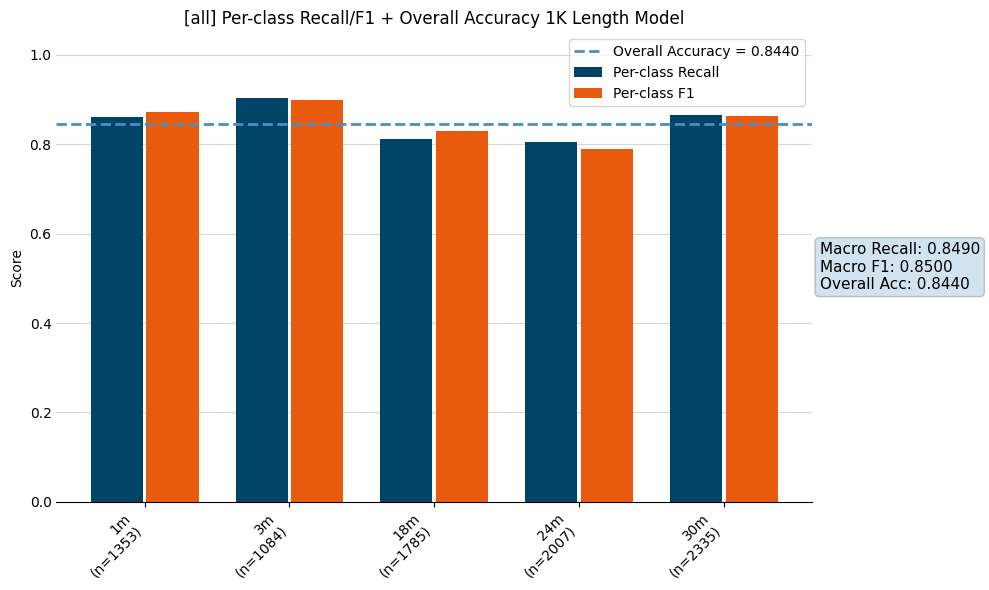

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_all_metrics.png


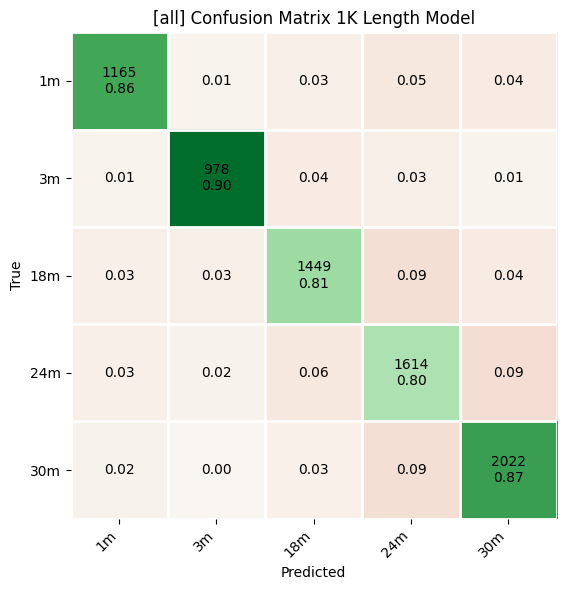

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_all_confusion_matrix.png


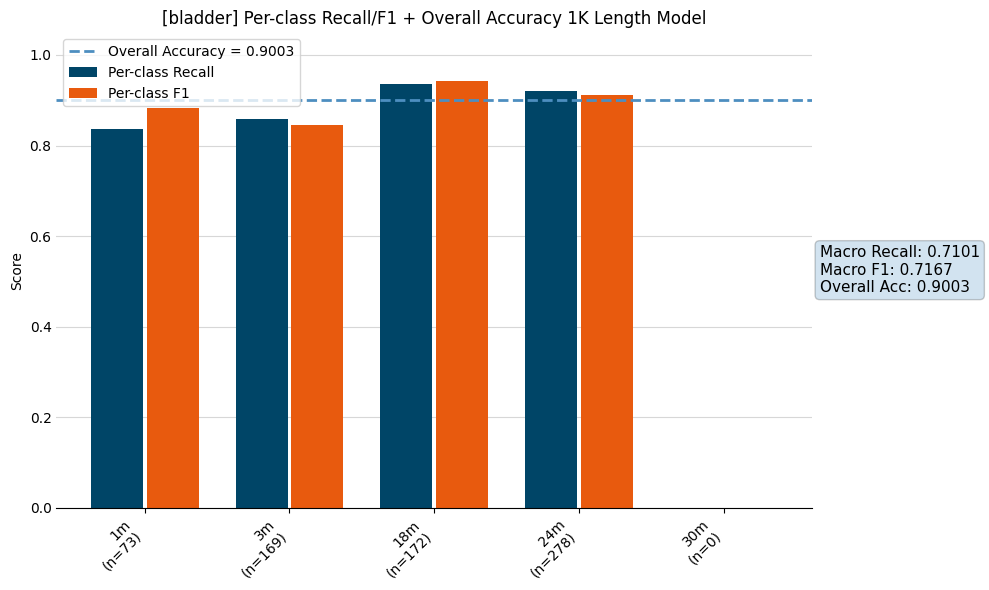

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_bladder_metrics.png


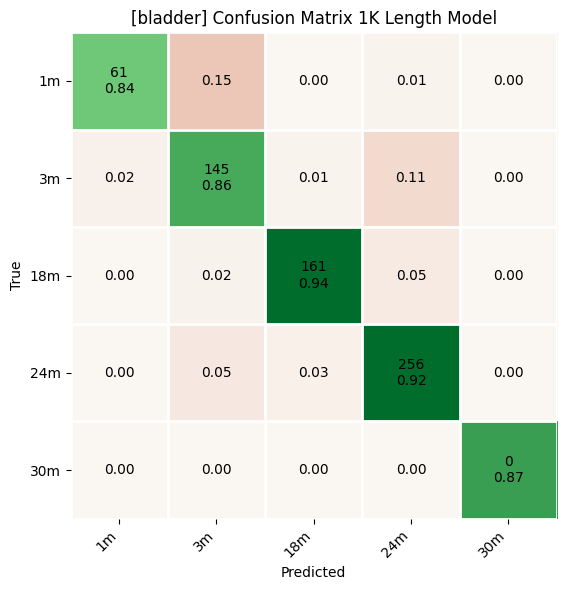

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_bladder_confusion_matrix.png


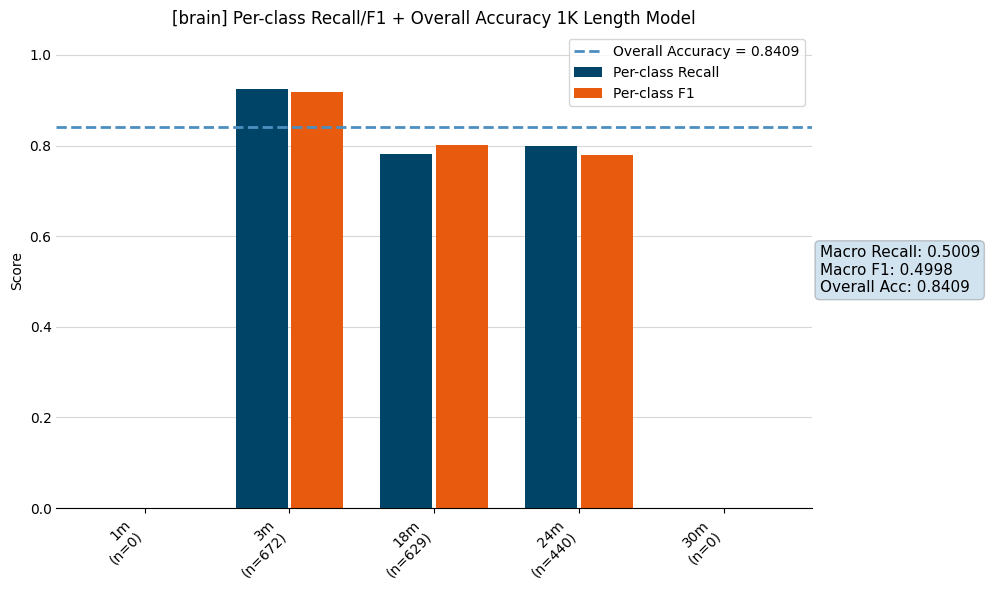

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_brain_metrics.png


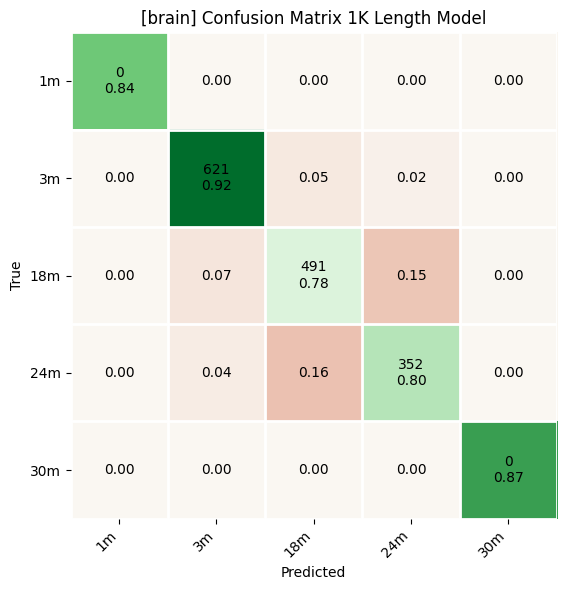

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_brain_confusion_matrix.png


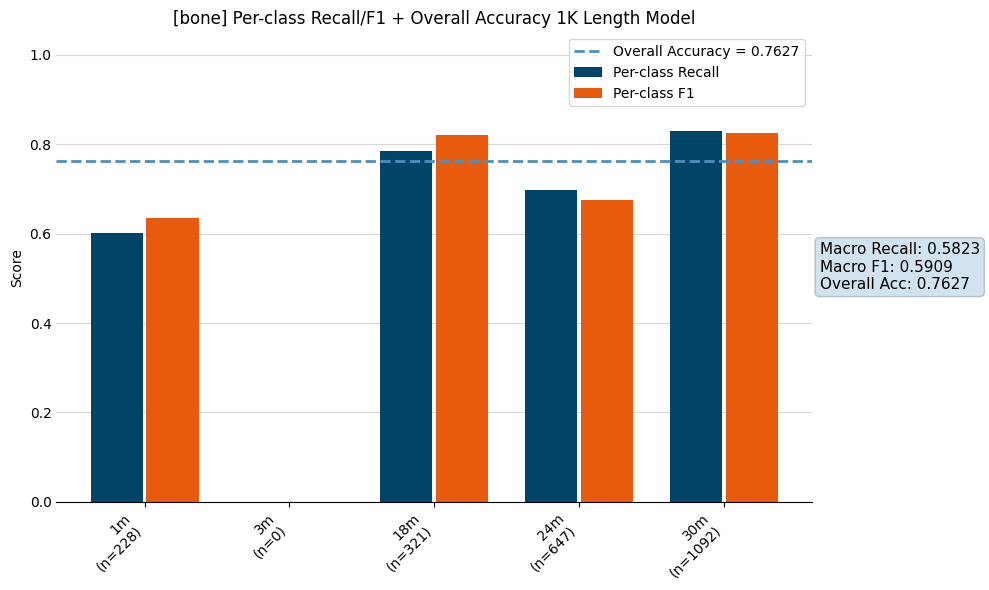

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_bone_metrics.png


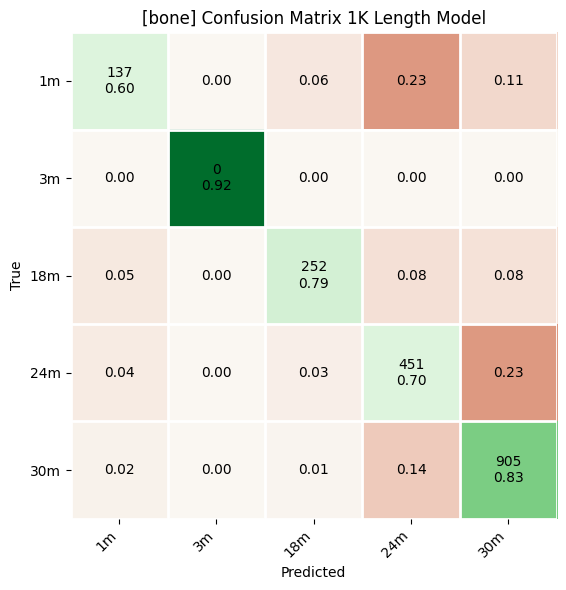

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_bone_confusion_matrix.png


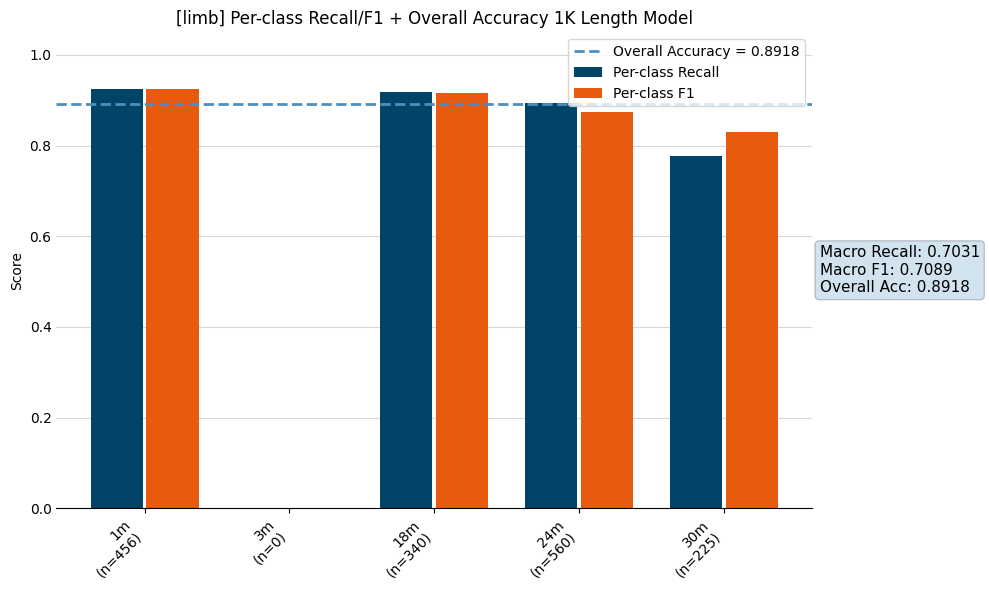

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_limb_metrics.png


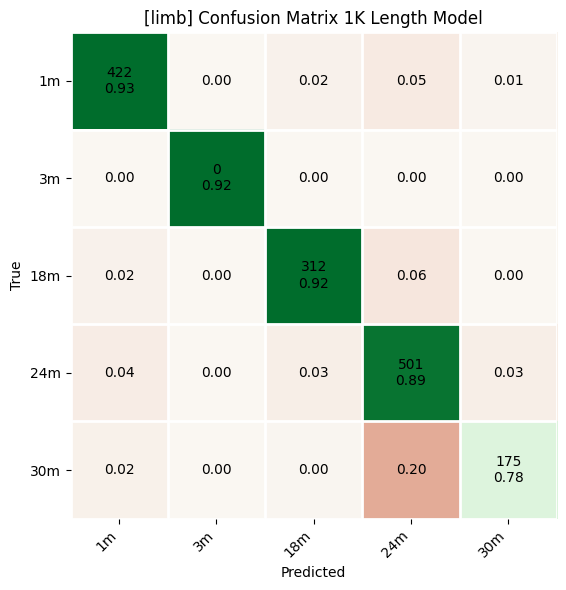

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_limb_confusion_matrix.png


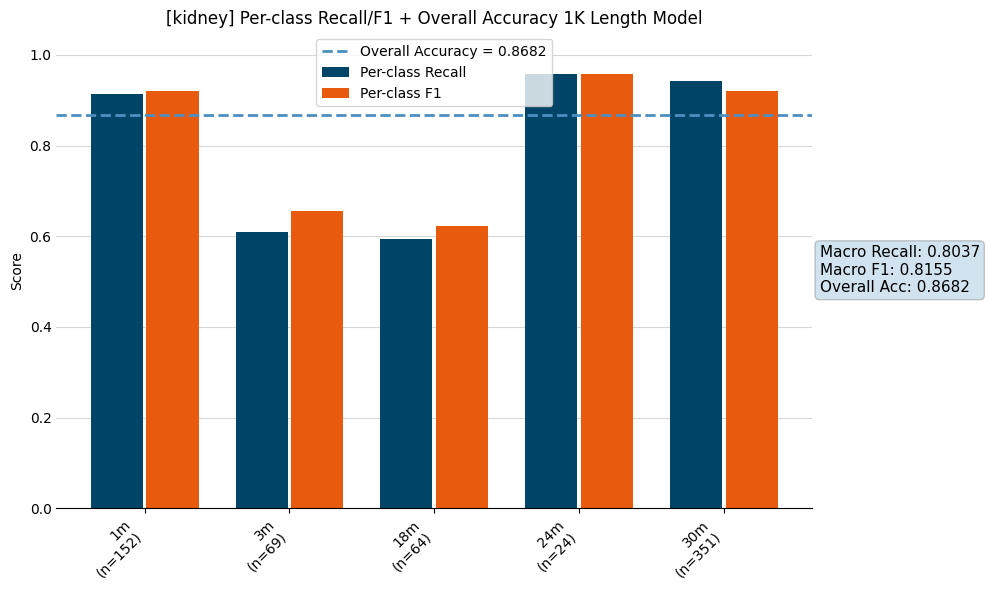

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_kidney_metrics.png


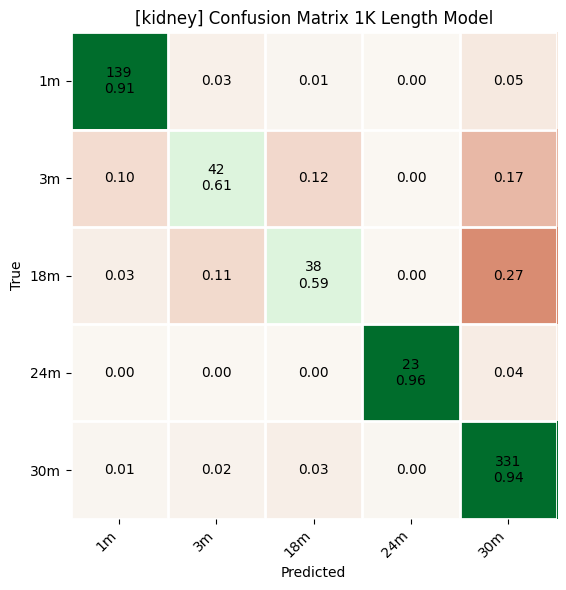

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_kidney_confusion_matrix.png


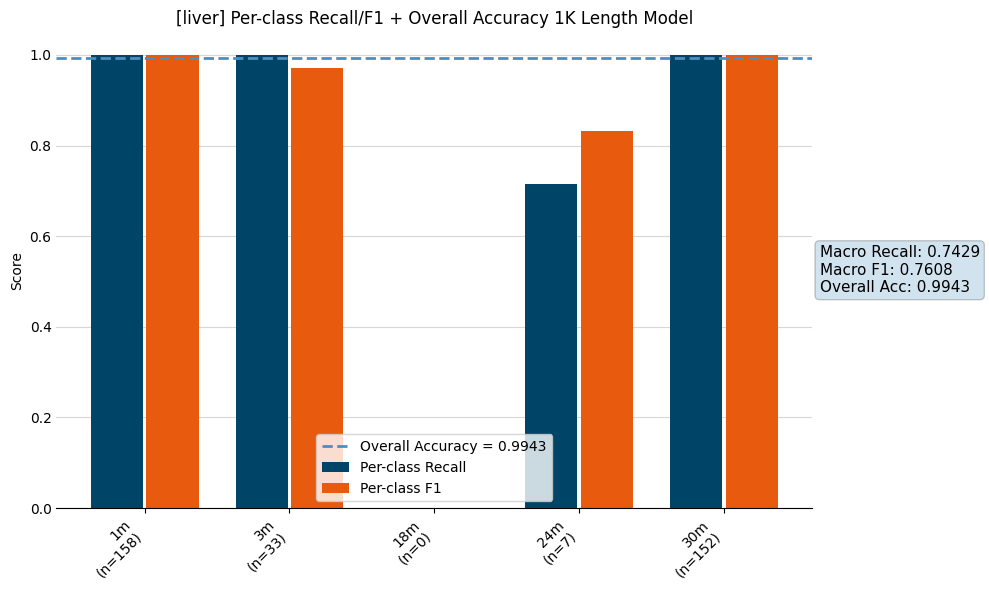

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_liver_metrics.png


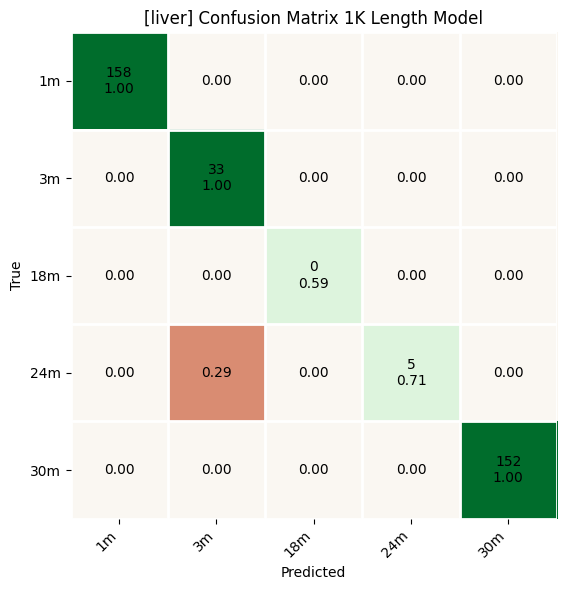

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_liver_confusion_matrix.png


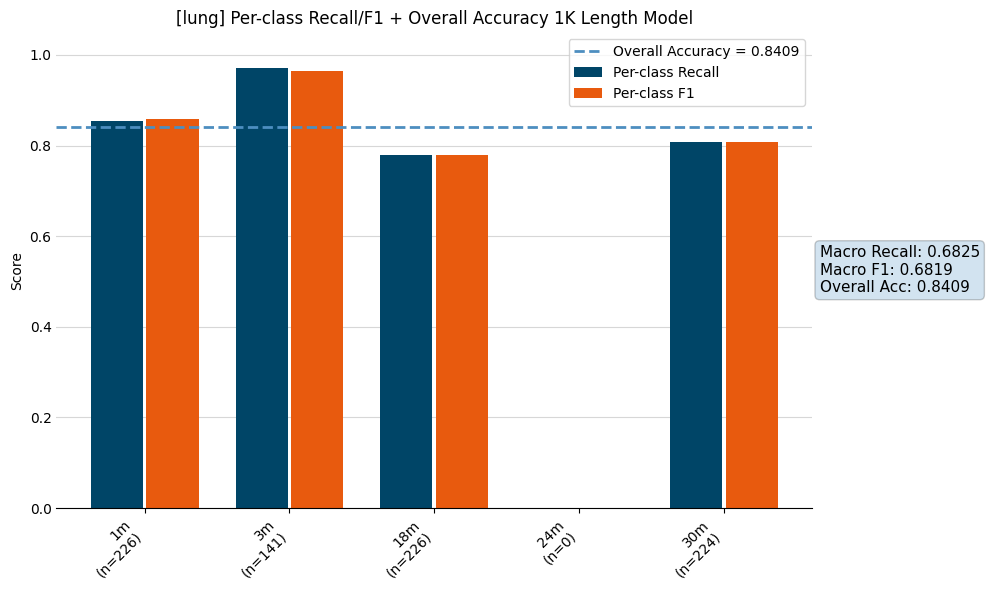

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_lung_metrics.png


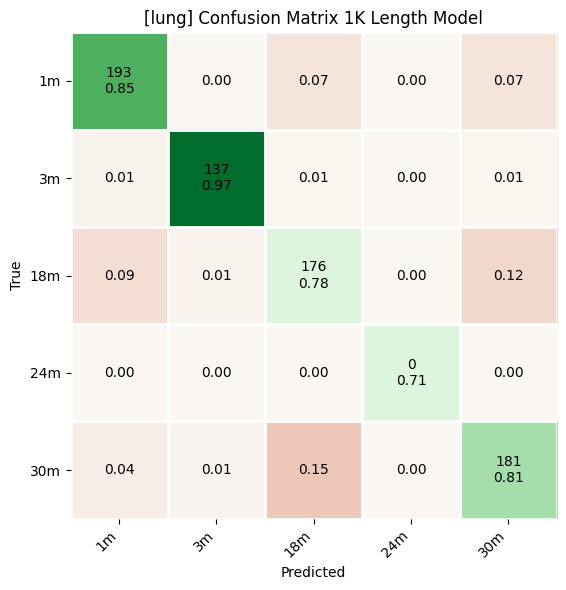

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_lung_confusion_matrix.png


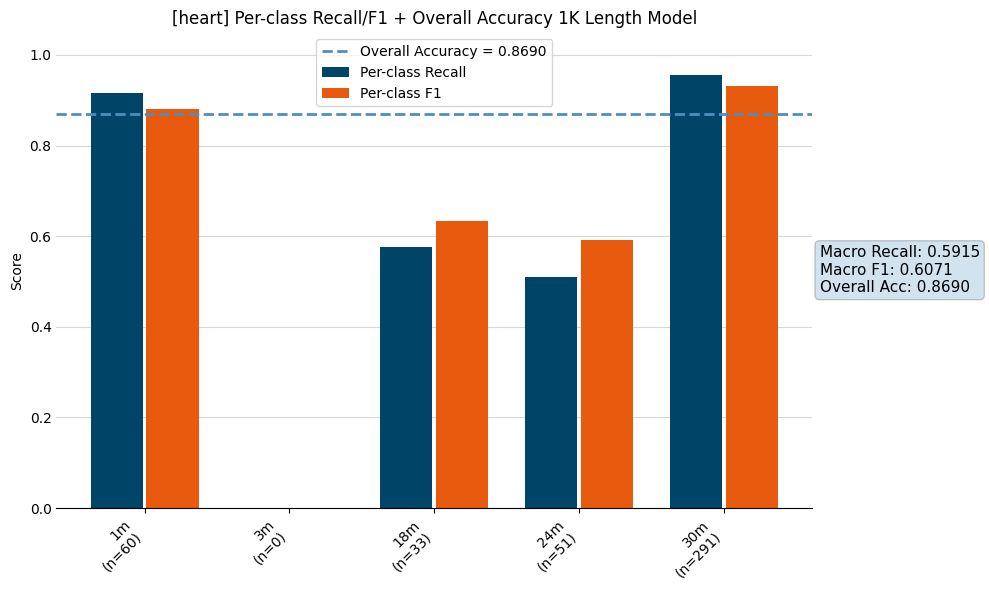

Saved metrics figure to: /content/qwen3_prediction_acc_outputs/final_heart_metrics.png


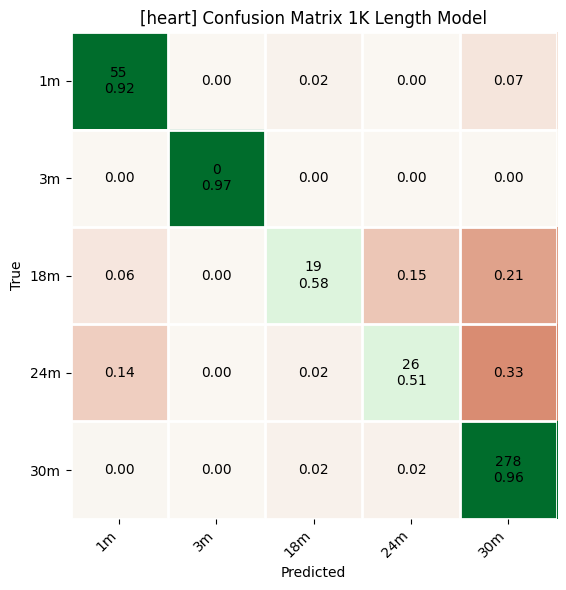

Saved confusion matrix figure to: /content/qwen3_prediction_acc_outputs/final_heart_confusion_matrix.png


In [ ]:
# Optional: reload results from disk if needed
details_path = os.path.join(OUTPUT_DIR, "final_eval_details_by_split.json")

with open(details_path, "r") as handle:
    results = json.load(handle)

for split_name in ["all"] + list(ORGAN_PREFIXES.keys()):
    split_result = results[split_name]

    plot_accuracy_f1_recall(split_result, OUTPUT_DIR)
    plot_confusion_matrix(split_result, OUTPUT_DIR)

## Session 8 - Print Per-Label Organ Summaries

Steps:
1. Print label-level recall for each organ split.


In [ ]:
print("\n===== Per-Category Accuracy by Organ =====")
for split_name, split_result in results.items():
    if split_name == "all":
        continue

    print(f"\n--- {split_name.upper()} ---")
    for label, score in split_result["per_label_accuracy_rowwise"].items():
        if np.isfinite(score):
            print(f"  {label}: {score:.4f}")
        else:
            print(f"  {label}: N/A (no samples)")



===== Per-Category Accuracy by Organ =====

--- BLADDER ---
  1m: 0.8356
  3m: 0.8580
  18m: 0.9360
  24m: 0.9209
  30m: N/A (no samples)

--- BRAIN ---
  1m: N/A (no samples)
  3m: 0.9241
  18m: 0.7806
  24m: 0.8000
  30m: N/A (no samples)

--- BONE ---
  1m: 0.6009
  3m: N/A (no samples)
  18m: 0.7850
  24m: 0.6971
  30m: 0.8288

--- LIMB ---
  1m: 0.9254
  3m: N/A (no samples)
  18m: 0.9176
  24m: 0.8946
  30m: 0.7778

--- KIDNEY ---
  1m: 0.9145
  3m: 0.6087
  18m: 0.5938
  24m: 0.9583
  30m: 0.9430

--- LIVER ---
  1m: 1.0000
  3m: 1.0000
  18m: N/A (no samples)
  24m: 0.7143
  30m: 1.0000

--- LUNG ---
  1m: 0.8540
  3m: 0.9716
  18m: 0.7788
  24m: N/A (no samples)
  30m: 0.8080

--- HEART ---
  1m: 0.9167
  3m: N/A (no samples)
  18m: 0.5758
  24m: 0.5098
  30m: 0.9553


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, r2_score

ORGAN_DISPLAY = {
    "bladder": "Bladder",
    "brain": "Brain",
    "bone": "Bone-Marrow",
    "limb": "Limb-Muscle",
    "kidney": "Kidney",
    "liver": "Liver",
    "lung": "Lung",
    "heart": "Heart",
}

ORGAN_COLORS = {
    "bladder": "#1f77b4",
    "bone": "#ff7f0e",
    "brain": "#2ca02c",
    "heart": "#d62728",
    "kidney": "#9467bd",
    "limb": "#8c564b",
    "liver": "#e377c2",
    "lung": "#7f7f7f",
    "heart": "#d62728",
}

def plot_organ_r2_summary(results: dict, output_dir: str) -> None:
    organ_order = ["bladder", "bone", "brain", "heart", "kidney", "limb", "liver", "lung"]

    plot_rows = []
    for organ in organ_order:
        if organ not in results:
            continue

        split_result = results[organ]
        report = split_result["classification_report"]

        y_true = []
        y_pred = []

        cm = np.array(split_result["confusion_matrix"]["matrix"], dtype=np.int64)
        labels = split_result["confusion_matrix"]["labels"]

        label_to_id = {label: i for i, label in enumerate(labels)}

        for true_idx, row in enumerate(cm):
            for pred_idx, count in enumerate(row):
                y_true.extend([true_idx] * count)
                y_pred.extend([pred_idx] * count)

        if len(set(y_true)) < 2:
            r2_value = float("nan")
        else:
            r2_value = float(r2_score(y_true, y_pred))

        plot_rows.append(
            {
                "organ": organ,
                "organ_display": ORGAN_DISPLAY.get(organ, organ.title()),
                "r_squared": r2_value,
                "n": split_result["num_samples"],
            }
        )

    plot_rows = [row for row in plot_rows if np.isfinite(row["r_squared"])]

    x_labels = [row["organ_display"] for row in plot_rows]
    y_values = [row["r_squared"] for row in plot_rows]
    bar_colors = [ORGAN_COLORS.get(row["organ"], "#7f7f7f") for row in plot_rows]

    fig, ax = plt.subplots(figsize=(12, 8))
    x = np.arange(len(plot_rows))
    ax.bar(x, y_values, color=bar_colors, width=0.72)

    ax.set_title("Model Performance Summary", fontsize=16, pad=14)
    ax.set_xlabel("Experiments", fontsize=14)
    ax.set_ylabel("Model R-squared Values", fontsize=14)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=12)

    legend_handles = [
        patches.Patch(color=ORGAN_COLORS[organ], label=ORGAN_DISPLAY.get(organ, organ.title()))
        for organ in organ_order
        if organ in results
    ]
    ax.legend(handles=legend_handles, title="Experiment", loc="upper right", frameon=True, fontsize=8, title_fontsize=8)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)

    fig_path = os.path.join(output_dir, "final_organ_r_squared_summary.png")
    plt.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved organ R-squared summary figure to:", fig_path)

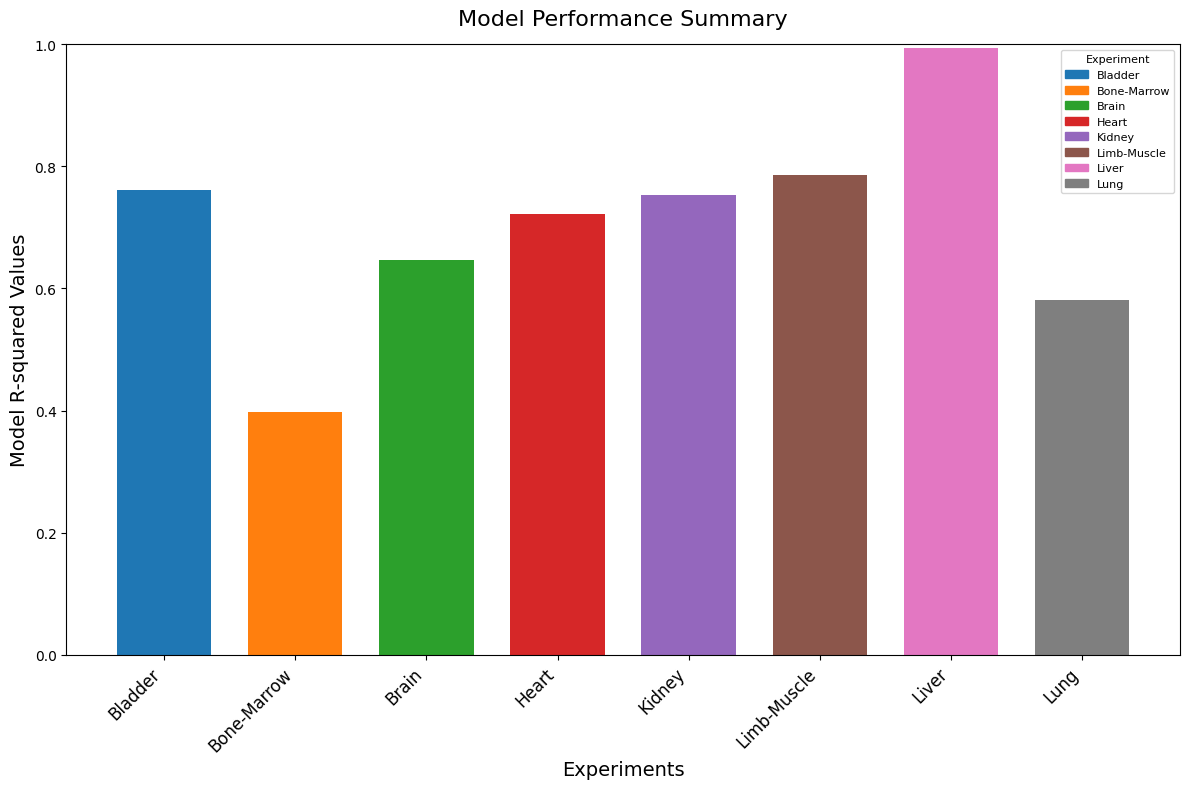

Saved organ R-squared summary figure to: /content/qwen3_prediction_acc_outputs/final_organ_r_squared_summary.png


In [22]:
plot_organ_r2_summary(results, OUTPUT_DIR)

## Session 9 - Optional Colab Cleanup

Steps:
1. Release the runtime after evaluation finishes.


In [ ]:
# from google.colab import runtime

# runtime.unassign()



## Session 10 - Download Figures to Google Drive

To persist the generated figures and make them accessible outside this Colab session, we'll move them to your Google Drive.

In [13]:
import shutil
import os

source_dir = OUTPUT_DIR
destination_dir_name = "qwen3_prediction_acc_figures"
destination_path = os.path.join("/content/drive/MyDrive/", destination_dir_name)

# Ensure the source directory exists and is not empty
if os.path.exists(source_dir) and os.listdir(source_dir):
    # Create the destination directory if it doesn't exist
    os.makedirs(destination_path, exist_ok=True)

    # Move all contents from the source to the destination
    for item_name in os.listdir(source_dir):
        source_item = os.path.join(source_dir, item_name)
        destination_item = os.path.join(destination_path, item_name)
        shutil.move(source_item, destination_item)
    print(f"All figures and evaluation outputs have been moved to: {destination_path}")
    print("You can now find them in your Google Drive under 'MyDrive/qwen3_prediction_acc_figures/'.")
else:
    print(f"Source directory {source_dir} does not exist or is empty. No files to move.")


All figures and evaluation outputs have been moved to: /content/drive/MyDrive/qwen3_prediction_acc_figures
You can now find them in your Google Drive under 'MyDrive/qwen3_prediction_acc_figures/'.
